## Multivariate Linear Regression for House Price Predicition

In [846]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [847]:
# Loading the dataset
df_housing = pd.read_csv("Datasets/housing_price_dataset.csv")
df_housing.head(3)

,SquareFeet,Bedrooms,Bathrooms,Neighborhood,YearBuilt,Price
0,2126,4,1,Rural,1969,215355.283618
1,2459,3,2,Rural,1980,195014.221626
2,1860,2,1,Suburb,1970,306891.012076


### EDA

In [848]:
df_housing.shape

(50000, 6)

In [849]:
df_housing.info() # Zero Nulls

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   SquareFeet    50000 non-null  int64  
 1   Bedrooms      50000 non-null  int64  
 2   Bathrooms     50000 non-null  int64  
 3   Neighborhood  50000 non-null  object 
 4   YearBuilt     50000 non-null  int64  
 5   Price         50000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 2.3+ MB


In [850]:
df_housing.describe()

,SquareFeet,Bedrooms,Bathrooms,YearBuilt,Price
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,2006.374680,3.498700,1.995420,1985.404420,224827.325151
std,575.513241,1.116326,0.815851,20.719377,76141.842966
min,1000.000000,2.000000,1.000000,1950.000000,-36588.165397
25%,1513.000000,3.000000,1.000000,1967.000000,169955.860225
50%,2007.000000,3.000000,2.000000,1985.000000,225052.141166
75%,2506.000000,4.000000,3.000000,2003.000000,279373.630052
max,2999.000000,5.000000,3.000000,2021.000000,492195.259972


In [851]:
df_housing.nunique()

SquareFeet       2000
Bedrooms            4
Bathrooms           3
Neighborhood        3
YearBuilt          72
Price           50000
dtype: int64

In [852]:
df_housing.columns

Index(['SquareFeet', 'Bedrooms', 'Bathrooms', 'Neighborhood', 'YearBuilt',
       'Price'],
      dtype='object')

In [853]:
# Price is the target
df_housing.dtypes

SquareFeet        int64
Bedrooms          int64
Bathrooms         int64
Neighborhood     object
YearBuilt         int64
Price           float64
dtype: object

In [854]:
X = df_housing.drop(columns="Price")
y = df_housing["Price"]

numfeatures = X.select_dtypes("number")
catfeatures = X.select_dtypes("object")

print(f"Numerical Features: {list(numfeatures.columns)}\nCategorical Features: {list(catfeatures.columns)}")

Numerical Features: ['SquareFeet', 'Bedrooms', 'Bathrooms', 'YearBuilt']
Categorical Features: ['Neighborhood']


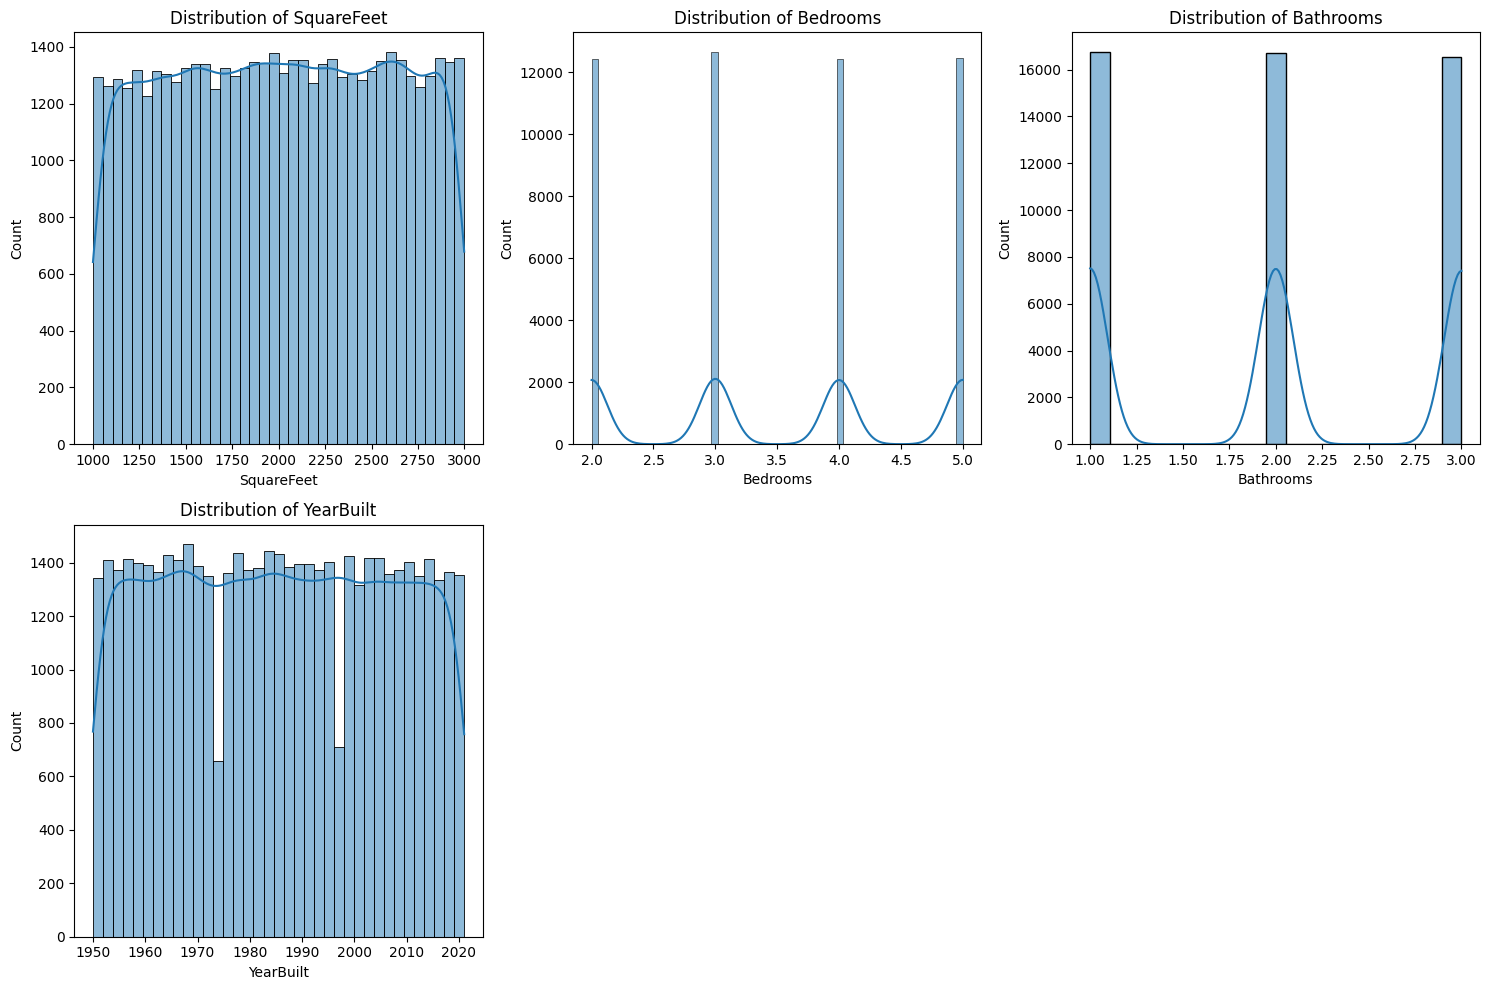

In [855]:
numfeatures_list = list(numfeatures)

plt.figure(figsize=(15,10))
for i, col in enumerate(numfeatures_list, 1):
    plt.subplot(2,3,i)
    sns.histplot(X[col], kde=True)
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

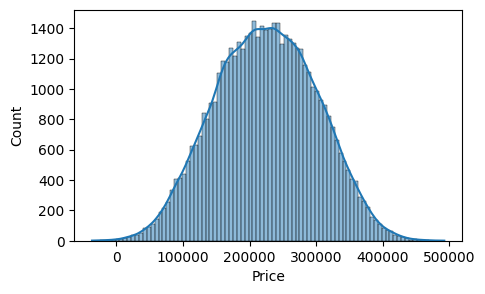

In [856]:
plt.figure(figsize=(5,3))
sns.histplot(df_housing["Price"], kde=True);

In [857]:
# Skewnes
df_housing[numfeatures_list].skew()

SquareFeet   -0.011162
Bedrooms      0.004640
Bathrooms     0.008408
YearBuilt     0.005557
dtype: float64

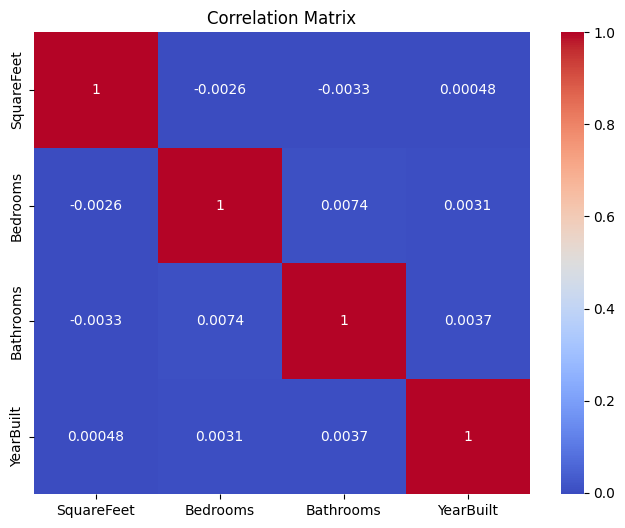

In [858]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_housing[numfeatures_list].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

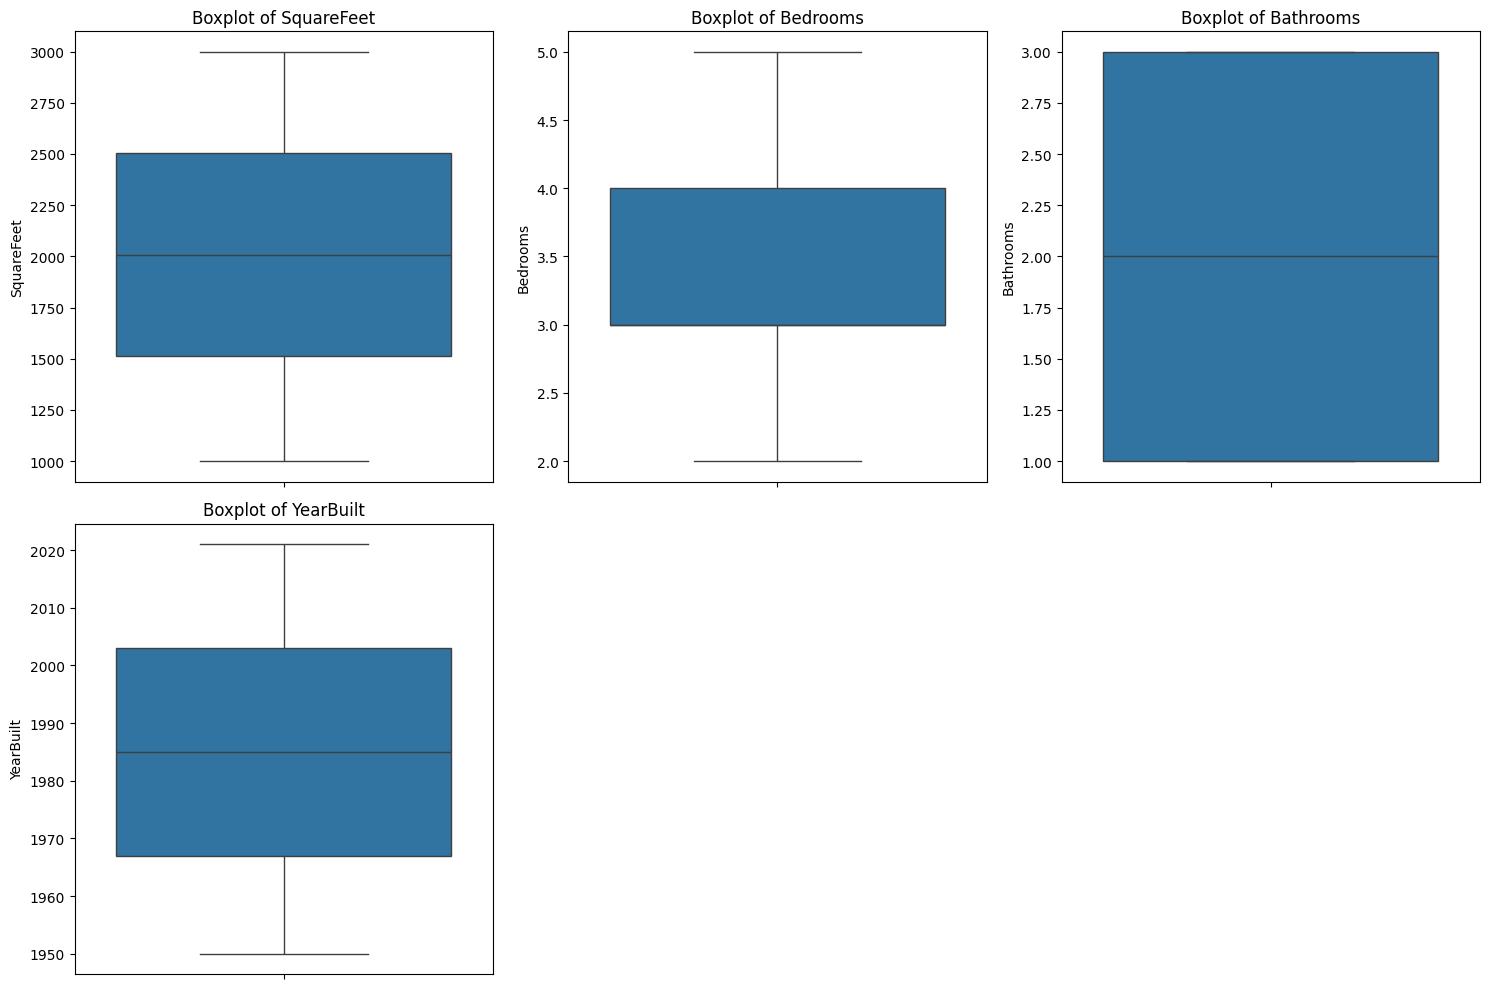

In [859]:
plt.figure(figsize=(15,10))
for i, col in enumerate(numfeatures_list, 1):
    plt.subplot(2,3,i)
    sns.boxplot(df_housing[col])
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

In [860]:
Q1 = df_housing['Price'].quantile(0.25)
Q3 = df_housing['Price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_housing[(df_housing['Price'] < lower_bound) | (df_housing['Price'] > upper_bound)]
not_outliers = df_housing[(df_housing['Price'] >= lower_bound) & (df_housing['Price'] <= upper_bound)]
print(f"Number of outliers: {len(outliers)}\nNumber of non outliers: {len(not_outliers)}")

# Negligible outlier count, so we keep them!


Number of outliers: 59
Number of non outliers: 49941


In [861]:
flag = False
count = 0
for i in range(df_housing["Bedrooms"].size):
    if df_housing["Bedrooms"].iloc[i] == 1: # No one bed room houses!
        print("One bedroom!")
        flag = True
        count += 1

print(count)
if not flag:
    print("No data points with only 1 bedroom!")

0
No data points with only 1 bedroom!


In [862]:
df_housing.head(20)

,SquareFeet,Bedrooms,Bathrooms,Neighborhood,YearBuilt,Price
0,2126,4,1,Rural,1969,215355.283618
1,2459,3,2,Rural,1980,195014.221626
2,1860,2,1,Suburb,1970,306891.012076
3,2294,2,1,Urban,1996,206786.787153
4,2130,5,2,Suburb,2001,272436.239065
5,2095,2,3,Suburb,2020,198208.803907
6,2724,2,1,Suburb,1993,343429.319110
7,2044,4,3,Rural,1957,184992.321268
8,2638,4,3,Urban,1959,377998.588152
9,1121,5,2,Urban,2004,95961.926014


In [863]:
# Data Transformation
# Neighbourhood can be observed as an Nominal Feature, One Hot Encode it

catfeatures = pd.get_dummies(catfeatures, columns=['Neighborhood'], drop_first=False)
catfeatures

,Neighborhood_Rural,Neighborhood_Suburb,Neighborhood_Urban
0,True,False,False
1,True,False,False
2,False,True,False
3,False,False,True
4,False,True,False
...,...,...,...
49995,True,False,False
49996,False,True,False
49997,False,True,False
49998,True,False,False


In [864]:
# For numerical, we scale
# We can treat Bedrooms, Bathrooms as Nominal, we one hot encode
numfeatures = pd.get_dummies(numfeatures, columns=["Bedrooms", "Bathrooms"], drop_first=False)
numfeatures

,SquareFeet,YearBuilt,Bedrooms_2,Bedrooms_3,Bedrooms_4,Bedrooms_5,Bathrooms_1,Bathrooms_2,Bathrooms_3
0,2126,1969,False,False,True,False,True,False,False
1,2459,1980,False,True,False,False,False,True,False
2,1860,1970,True,False,False,False,True,False,False
3,2294,1996,True,False,False,False,True,False,False
4,2130,2001,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...
49995,1282,1975,False,False,False,True,False,False,True
49996,2854,1988,True,False,False,False,False,True,False
49997,2979,1962,False,False,False,True,False,False,True
49998,2596,1984,False,False,False,True,False,True,False


In [865]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
numfeatures[['SquareFeet', 'YearBuilt']] = scaler.fit_transform(numfeatures[['SquareFeet', 'YearBuilt']])

In [866]:
numfeatures

,SquareFeet,YearBuilt,Bedrooms_2,Bedrooms_3,Bedrooms_4,Bedrooms_5,Bathrooms_1,Bathrooms_2,Bathrooms_3
0,0.207861,-0.791751,False,False,True,False,True,False,False
1,0.786480,-0.260842,False,True,False,False,False,True,False
2,-0.254340,-0.743486,True,False,False,False,True,False,False
3,0.499777,0.511390,True,False,False,False,True,False,False
4,0.214811,0.752713,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...
49995,-1.258671,-0.502164,False,False,False,True,False,False,True
49996,1.472831,0.125274,True,False,False,False,False,True,False
49997,1.690031,-1.129602,False,False,False,True,False,False,True
49998,1.024531,-0.067784,False,False,False,True,False,True,False


In [867]:
catfeatures

,Neighborhood_Rural,Neighborhood_Suburb,Neighborhood_Urban
0,True,False,False
1,True,False,False
2,False,True,False
3,False,False,True
4,False,True,False
...,...,...,...
49995,True,False,False
49996,False,True,False
49997,False,True,False
49998,True,False,False


In [868]:
final_df = pd.concat([numfeatures, catfeatures], axis=1)
final_df

,SquareFeet,YearBuilt,Bedrooms_2,Bedrooms_3,Bedrooms_4,Bedrooms_5,Bathrooms_1,Bathrooms_2,Bathrooms_3,Neighborhood_Rural,Neighborhood_Suburb,Neighborhood_Urban
0,0.207861,-0.791751,False,False,True,False,True,False,False,True,False,False
1,0.786480,-0.260842,False,True,False,False,False,True,False,True,False,False
2,-0.254340,-0.743486,True,False,False,False,True,False,False,False,True,False
3,0.499777,0.511390,True,False,False,False,True,False,False,False,False,True
4,0.214811,0.752713,False,False,False,True,False,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
49995,-1.258671,-0.502164,False,False,False,True,False,False,True,True,False,False
49996,1.472831,0.125274,True,False,False,False,False,True,False,False,True,False
49997,1.690031,-1.129602,False,False,False,True,False,False,True,False,True,False
49998,1.024531,-0.067784,False,False,False,True,False,True,False,True,False,False


In [869]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

X = final_df
y = df_housing["Price"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [870]:
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R² Score: {r2:.4f}")

MSE: 2733816043.76
RMSE: 52285.91
MAE: 41656.42
R² Score: 0.5237


In [871]:
mape = np.mean(np.abs((y_test - y_pred) / y_test))
print(f"MAPE (as decimal): {mape:.3f}")

MAPE (as decimal): 0.272


In [872]:
pred_true = pd.DataFrame({
    "True": y_test,
    "Pred": y_pred
})

pred_true.head(10)

,True,Pred
33553,170835.035713,215033.538723
9427,126913.469998,143267.809697
199,246611.883092,269576.292680
12447,244250.462969,319142.967912
39489,271127.650112,266803.738672
42724,189289.951199,246196.768059
10822,343510.576500,298918.529201
49498,203461.591080,193748.770492
4144,285903.247682,317808.193737
36958,224868.958375,247838.500904
